# Latent predictability and batch intervention

Three paired structured/plain VAE repetitions on scIB pancreas. The dose-response experiment uses conditional diffusion trained on these same VAEs. This notebook reads the saved measurements and displays the figures inline.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

%config InlineBackend.figure_format = 'retina'
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False})

## Runs and appearance

Set the two completed run directories below. Both experiments must reference the same VAE pairs. Sizes and font scale are the only presentation controls.

In [2]:
PROJECT_ROOT = Path('/Users/malangtian/Documents/Research_Projects/scDiffusion_project/scDeepSim')
VAE_RUN = PROJECT_ROOT / 'experiments/outputs/structured_batch_intervention_20260907/latent_predictability'
DOSE_RUN = PROJECT_ROOT / 'experiments/outputs/structured_batch_intervention_20260907/dose_response'

HEATMAP_SIZE = (10, 5.5)
DOSE_SIZE = (13, 5.5)
COMPOSITE_SIZE = (23, 6)
FONT_SIZE = 10
plt.rcParams.update({'font.size': FONT_SIZE})

## Load the completed measurements

In [3]:
predictability = pd.read_csv(VAE_RUN / 'results/latent_predictability.csv')
predictability_summary = pd.read_csv(VAE_RUN / 'results/latent_predictability_summary.csv')
dose = pd.read_csv(DOSE_RUN / 'results/dose_response_metrics.csv')
dose_summary = pd.read_csv(DOSE_RUN / 'results/dose_response_summary.csv')
vae_metadata = json.loads((VAE_RUN / 'results/metadata.json').read_text())
dose_metadata = json.loads((DOSE_RUN / 'results/metadata.json').read_text())

assert vae_metadata['complete'] and dose_metadata['complete']
assert Path(dose_metadata['source_vae_run']).resolve() == VAE_RUN.resolve()
assert vae_metadata['seeds'] == dose_metadata['seeds']
assert predictability_summary['n_replicates'].eq(len(vae_metadata['seeds'])).all()
assert dose_summary['n_replicates'].eq(len(vae_metadata['seeds'])).all()
print(f"Seeds: {vae_metadata['seeds']} | Predictability: {len(predictability)} rows | Dose response: {len(dose)} rows")

Seeds: [42, 43, 44] | Predictability: 36 rows | Dose response: 42 rows


## Latent predictability

Color shows structured-VAE mean balanced accuracy on a fixed 0–1 scale. Each cell also gives the plain-VAE result on the same coordinates. Error terms are sample SD across repetitions. The plain model's coordinate blocks have no supervised biological assignment.

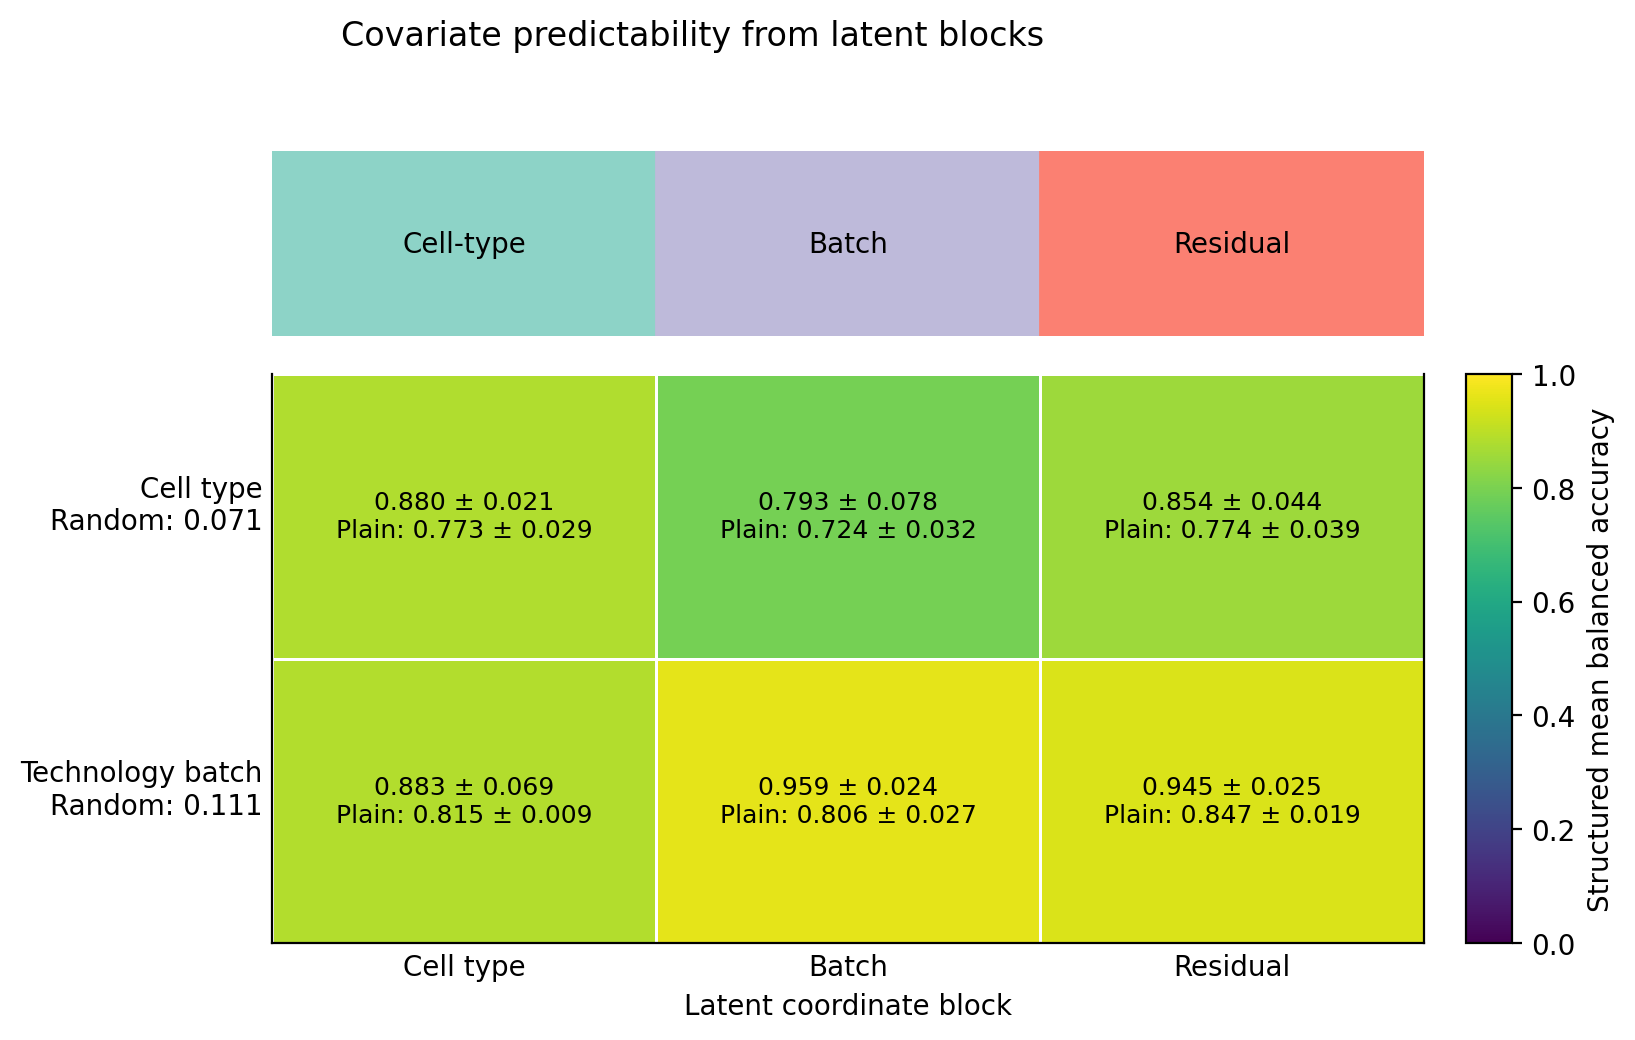

In [ ]:
BLOCKS = ['z_celltype', 'z_batch', 'z_residual']
BLOCK_NAMES = ['Cell-type', 'Batch', 'Residual block']
TARGETS = ['celltype', 'batch']
TARGET_NAMES = ['Cell type', 'Technology batch']
BLOCK_COLORS = ['#8dd3c7', '#bebada', '#fb8072']
heat_stats = predictability_summary.set_index(['model', 'label', 'subspace'])


def mean_sd(mean, sd):
    return f'{mean:.3f}' if pd.isna(sd) else f'{mean:.3f} ± {sd:.3f}'


def draw_predictability(fig):
    grid = fig.add_gridspec(2, 2, height_ratios=[0.65, 2], width_ratios=[1, 0.04],
                           left=0.29, right=0.91, bottom=0.13, top=0.85,
                           hspace=0.10, wspace=0.07)
    schematic = fig.add_subplot(grid[0, 0])
    ax = fig.add_subplot(grid[1, 0])
    for column, block in enumerate(BLOCKS):
        dimensions = vae_metadata['subspace_slices'][block]['dim']
        schematic.add_patch(plt.Rectangle((column, 0), 1, 1, color=BLOCK_COLORS[column]))
        schematic.text(column + 0.5, 0.5, f'{BLOCK_NAMES[column]}',
                       ha='center', va='center', fontsize=FONT_SIZE)
    schematic.set(xlim=(0, 3), ylim=(0, 1))
    schematic.axis('off')
    matrix = np.array([[heat_stats.loc[('structured', target, block), 'balanced_accuracy_mean']
                        for block in BLOCKS] for target in TARGETS])
    mesh = ax.pcolormesh(np.arange(4), np.arange(3), matrix, vmin=0, vmax=1,
                         cmap='viridis', edgecolors='white', linewidth=1)
    row_labels = []
    for row, target in enumerate(TARGETS):
        reference = heat_stats.loc[('structured', target, BLOCKS[0])]
        row_labels.append(f"{TARGET_NAMES[row]}\nRandom: {reference['random_ba_mean']:.3f}\n"
                        #   f"Conditional majority:\n{mean_sd(reference['conditional_ba_mean'], reference['conditional_ba_sd'])}"
                          )
        for column, block in enumerate(BLOCKS):
            structured = heat_stats.loc[('structured', target, block)]
            plain = heat_stats.loc[('plain', target, block)]
            annotation = mean_sd(structured['balanced_accuracy_mean'], structured['balanced_accuracy_sd'])
            annotation += '\nPlain: ' + mean_sd(plain['balanced_accuracy_mean'], plain['balanced_accuracy_sd'])
            color = 'white' if matrix[row, column] < 0.55 else 'black'
            ax.text(column + 0.5, row + 0.5, annotation, ha='center', va='center',
                    color=color, fontsize=FONT_SIZE - 1)
    ax.set(xticks=np.arange(3) + 0.5, xticklabels=['Cell type', 'Batch', 'Residual'],
           yticks=np.arange(2) + 0.5, yticklabels=row_labels, xlabel='Latent coordinate block')
    ax.invert_yaxis()
    ax.tick_params(length=0)
    cbar = fig.colorbar(mesh, cax=fig.add_subplot(grid[1, 1]))
    cbar.set_label('Structured mean balanced accuracy')


fig = plt.figure(figsize=HEATMAP_SIZE)
draw_predictability(fig)
fig.suptitle('Covariate predictability from latent blocks', y=0.97)
plt.show()

## Batch dose response

Both arms use de novo conditional diffusion samples. Whitening–recoloring acts on the structured batch block and the entire plain latent space. A remains fixed; B is intervened at each α. Batch ASW/iLISI use A+B; biological metrics use B. ASW/LISI use one fixed real-data PCA, and RF uses decoded expression.

Points show individual repetitions; curves and shading show mean ± sample SD. α = 1 applies the observed endpoint map; larger values extrapolate.

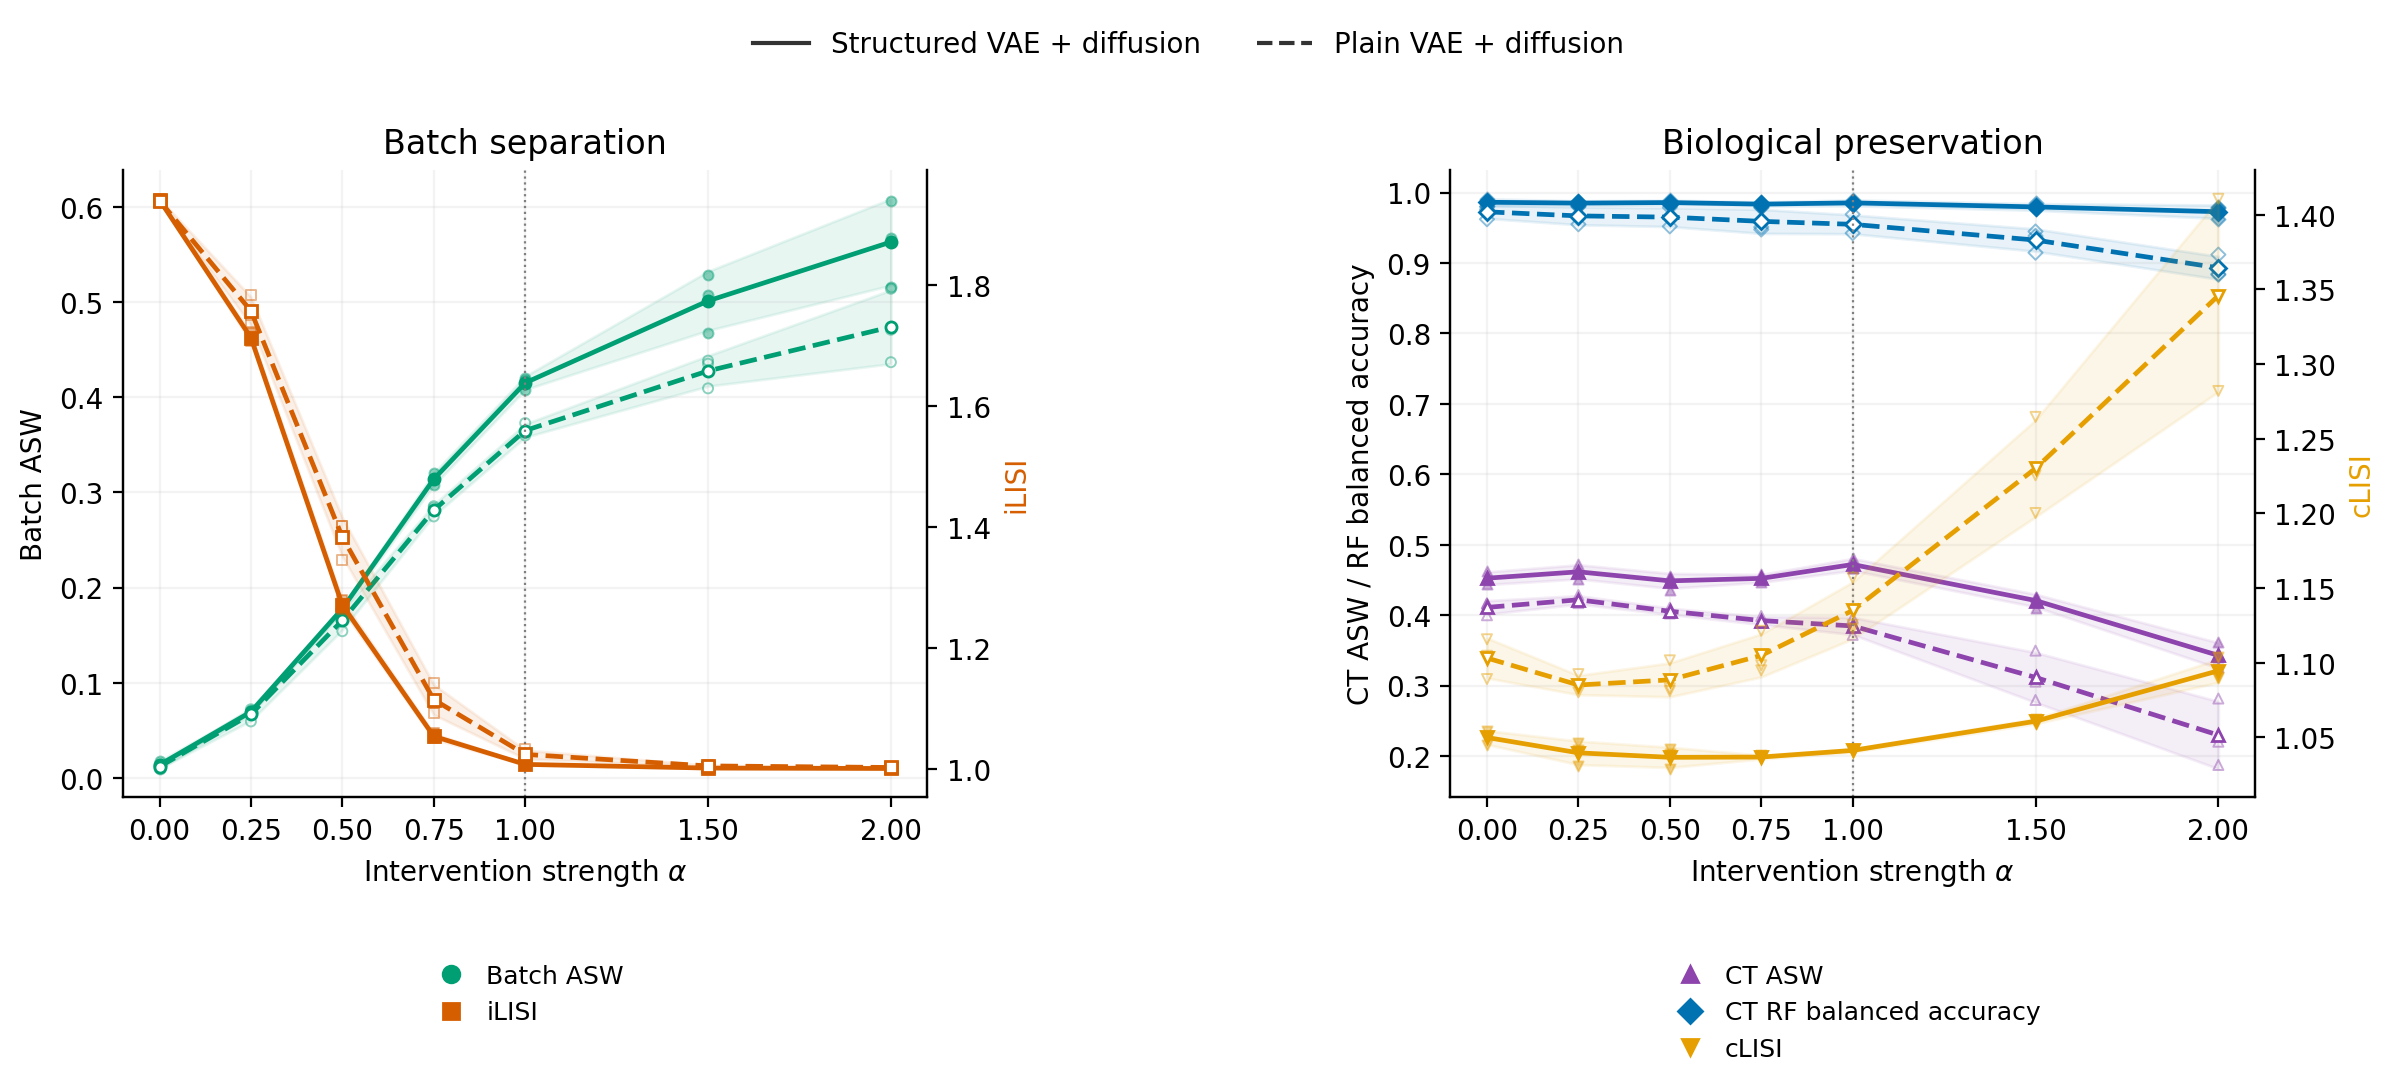

In [5]:
METRIC_STYLES = {
    'batch_asw': ('Batch ASW', '#009E73', 'o'),
    'ilisi': ('iLISI', '#D55E00', 's'),
    'celltype_asw': ('CT ASW', '#8E44AD', '^'),
    'celltype_rf_bal_acc': ('CT RF balanced accuracy', '#0072B2', 'D'),
    'clisi': ('cLISI', '#E69F00', 'v'),
}
MODEL_STYLES = {'structured': ('Structured VAE + diffusion', '-'),
                'plain': ('Plain VAE + diffusion', '--')}


def draw_curve(ax, metric):
    label, color, marker = METRIC_STYLES[metric]
    for model, (_, line_style) in MODEL_STYLES.items():
        summary = dose_summary[dose_summary['model'] == model].sort_values('alpha')
        x = summary['alpha'].to_numpy()
        mean = summary[f'{metric}_mean'].to_numpy()
        sd = summary[f'{metric}_sd'].to_numpy()
        ax.plot(x, mean, color=color, linestyle=line_style, marker=marker,
                markersize=4, linewidth=1.7,
                markerfacecolor=color if model == 'structured' else 'white')
        if np.isfinite(sd).all():
            ax.fill_between(x, mean - sd, mean + sd, color=color, alpha=0.09)
        raw = dose[dose['model'] == model]
        ax.scatter(raw['alpha'], raw[metric], s=13, marker=marker,
                   facecolors=color if model == 'structured' else 'none',
                   edgecolors=color, alpha=0.45, linewidths=0.7)


def draw_dose_response(fig):
    grid = fig.add_gridspec(1, 2, left=0.09, right=0.91, bottom=0.25, top=0.82, wspace=0.65)
    batch_ax, bio_ax = fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1])
    ilisi_ax, clisi_ax = batch_ax.twinx(), bio_ax.twinx()
    for axis, metric in [(batch_ax, 'batch_asw'), (ilisi_ax, 'ilisi'),
                         (bio_ax, 'celltype_asw'), (bio_ax, 'celltype_rf_bal_acc'),
                         (clisi_ax, 'clisi')]:
        draw_curve(axis, metric)
    batch_ax.set(title='Batch separation', ylabel='Batch ASW')
    ilisi_ax.set_ylabel('iLISI', color=METRIC_STYLES['ilisi'][1])
    bio_ax.set(title='Biological preservation', ylabel='CT ASW / RF balanced accuracy')
    clisi_ax.set_ylabel('cLISI', color=METRIC_STYLES['clisi'][1])
    for axis in (batch_ax, bio_ax):
        axis.set_xlabel(r'Intervention strength $\alpha$')
        axis.set_xticks(dose_metadata['alpha_values'])
        axis.axvline(1, color='0.5', linewidth=0.8, linestyle=':')
        axis.grid(alpha=0.15)
    for axis, metrics in [(batch_ax, ['batch_asw', 'ilisi']),
                          (bio_ax, ['celltype_asw', 'celltype_rf_bal_acc', 'clisi'])]:
        handles = [Line2D([], [], color=METRIC_STYLES[m][1], marker=METRIC_STYLES[m][2],
                          linestyle='', label=METRIC_STYLES[m][0]) for m in metrics]
        axis.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.23),
                    ncol=1, frameon=False, fontsize=FONT_SIZE - 1, handletextpad=0.4)
    handles = [Line2D([], [], color='0.2', linestyle=style, label=label)
               for label, style in MODEL_STYLES.values()]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=2, frameon=False)


fig = plt.figure(figsize=DOSE_SIZE)
draw_dose_response(fig)
plt.show()

## Interpretation

- Predictability uses RF-held-out cells within the dataset; these cells may have participated in VAE training. Substantial predictability in non-target blocks remains.
- Dose-response RF is refitted at each α and measures cell-type separability. These measurements do not establish manipulated-sample realism.
- The supplied `counts` layer contains non-integer values. The native decoder uses finite-retry rejection sampling, which can add zeros at stronger interventions.

The [experiment report](../../notes/Journals/latent_predictability_report.md) records the measured comparison, input details, and a decoder-sampling diagnostic.